In [1]:
pip install pandas numpy matplotlib seaborn openpyxl

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
forest_file = "A:/Data Analytics/bird/Bird_Monitoring_Data_FOREST.XLSX"
grass_file = "A:/Data Analytics/bird/Bird_Monitoring_Data_GRASSLAND.XLSX"
forest_excel = pd.ExcelFile(forest_file)
grass_excel = pd.ExcelFile(grass_file)

In [9]:
forest_sheets = forest_excel.sheet_names
grass_sheets = grass_excel.sheet_names

print("Forest Sheets:", forest_sheets)
print("Grass Sheets:", grass_sheets)

Forest Sheets: ['ANTI', 'CATO', 'CHOH', 'GWMP', 'HAFE', 'MANA', 'MONO', 'NACE', 'PRWI', 'ROCR', 'WOTR']
Grass Sheets: ['ANTI', 'CATO', 'CHOH', 'GWMP', 'HAFE', 'MANA', 'MONO', 'NACE', 'PRWI', 'ROCR', 'WOTR']


In [11]:
forest_data = []

for sheet in forest_sheets:
    df = pd.read_excel(forest_file, sheet_name=sheet)

    df['Admin_Unit'] = sheet
    df['Habitat_Type'] = 'Forest'

    forest_data.append(df)

forest_df = pd.concat(forest_data, ignore_index=True)

In [17]:
grass_data = []

for sheet in grass_sheets:
    df = pd.read_excel(grass_file, sheet_name=sheet)

    df['Admin_Unit'] = sheet
    df['Habitat_Type'] = 'Grassland'

    grass_data.append(df)

grass_df = pd.concat(grass_data, ignore_index=True)

C:\Users\gokul\AppData\Local\Temp\ipykernel_14972\1818030924.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  grass_df = pd.concat(grass_data, ignore_index=True)


In [19]:
final_df = pd.concat([forest_df, grass_df], ignore_index=True)

In [21]:
print("Forest rows:", forest_df.shape)
print("Grass rows:", grass_df.shape)
print("Final rows:", final_df.shape)

Forest rows: (8546, 31)
Grass rows: (8531, 31)
Final rows: (17077, 33)


In [35]:
final_df = final_df.drop_duplicates()

In [39]:
# Remove extra spaces
final_df.columns = final_df.columns.str.strip()

# Convert boolean to count
final_df['Count'] = final_df['Initial_Three_Min_Cnt'].astype(int)

# Fix date
final_df['Date'] = pd.to_datetime(final_df['Date'], errors='coerce')

# ❌ DO NOT use full dropna()

# ✅ Remove duplicates only
final_df = final_df.drop_duplicates()

# Final shape
print(final_df.shape)

(15372, 34)


In [41]:
final_df[['Common_Name', 'Habitat_Type', 'Count']].head(20)

,Common_Name,Habitat_Type,Count
0,Eastern Towhee,Forest,1
1,White-breasted Nuthatch,Forest,1
2,Red-bellied Woodpecker,Forest,0
3,Orchard Oriole,Forest,0
4,Northern Mockingbird,Forest,0
5,Northern Cardinal,Forest,0
6,Northern Cardinal,Forest,1
7,Horned Lark,Forest,1
8,Mourning Dove,Forest,1
9,Field Sparrow,Forest,0


In [47]:
final_df['Initial_Three_Min_Cnt'].value_counts()

Initial_Three_Min_Cnt
True     8249
False    7123
Name: count, dtype: int64

In [51]:
final_df.groupby('Habitat_Type')['Count'].sum()

Habitat_Type
Forest       4679
Grassland    3570
Name: Count, dtype: int32

In [55]:
final_df.duplicated(subset=['Date','Common_Name','Admin_Unit']).sum()

12659

In [59]:
habitat = final_df.groupby('Habitat_Type')['Count'].sum()
print((habitat / habitat.sum()) * 100)

Habitat_Type
Forest       56.722027
Grassland    43.277973
Name: Count, dtype: float64


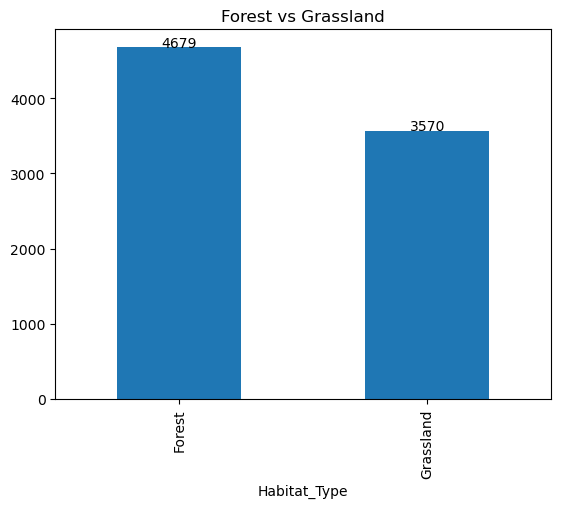

In [57]:
import matplotlib.pyplot as plt

habitat_data = final_df.groupby('Habitat_Type')['Count'].sum()

ax = habitat_data.plot(kind='bar')

plt.title("Forest vs Grassland")

# ✅ Add data labels
for i, v in enumerate(habitat_data):
    ax.text(i, v + 1, str(v), ha='center')

plt.show()

In [61]:
final_df['Count'] = final_df['Initial_Three_Min_Cnt'].astype(int)
final_df['Date'] = pd.to_datetime(final_df['Date'], errors='coerce')
final_df['Month'] = final_df['Date'].dt.month

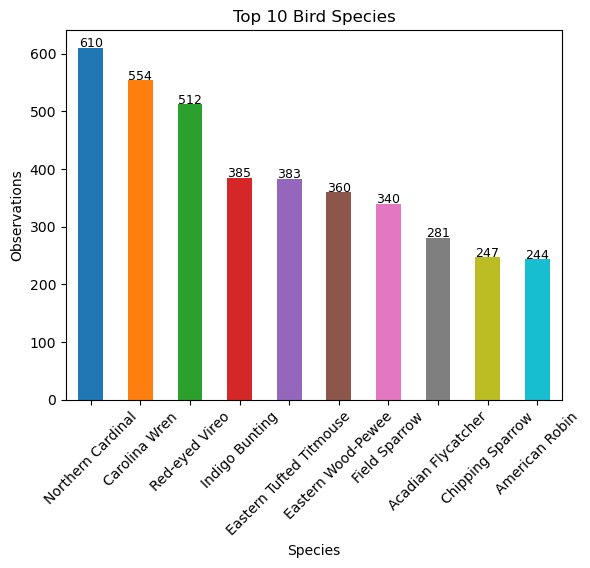

In [63]:
import matplotlib.pyplot as plt

top_species = final_df.groupby('Common_Name')['Count'].sum() \
                     .sort_values(ascending=False).head(10)

colors = plt.cm.tab10.colors  # auto color palette

ax = top_species.plot(kind='bar', color=colors)

plt.title("Top 10 Bird Species")
plt.xlabel("Species")
plt.ylabel("Observations")
plt.xticks(rotation=45)

# ✅ Add data labels
for i, v in enumerate(top_species):
    ax.text(i, v + 1, str(v), ha='center', fontsize=9)

plt.show()

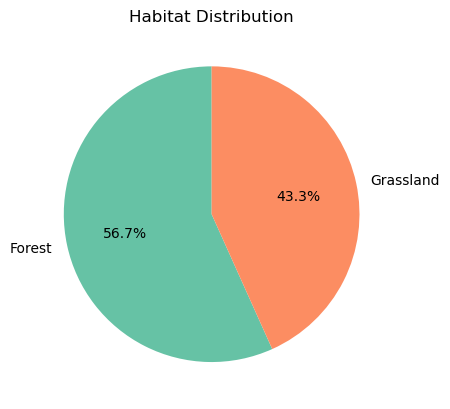

In [65]:
habitat_data = final_df.groupby('Habitat_Type')['Count'].sum()

colors = ['#66c2a5', '#fc8d62']

habitat_data.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)

plt.title("Habitat Distribution")
plt.ylabel("")
plt.show()

hhvh


In [ ]:
monthly = final_df.groupby('Month')['Count'].sum()

plt.plot(monthly.index, monthly.values, marker='o')

plt.title("Monthly Bird Activity")
plt.xlabel("Month")
plt.ylabel("Observations")

# ✅ Data labels
for x, y in zip(monthly.index, monthly.values):
    plt.text(x, y, str(y), ha='center')

plt.show()

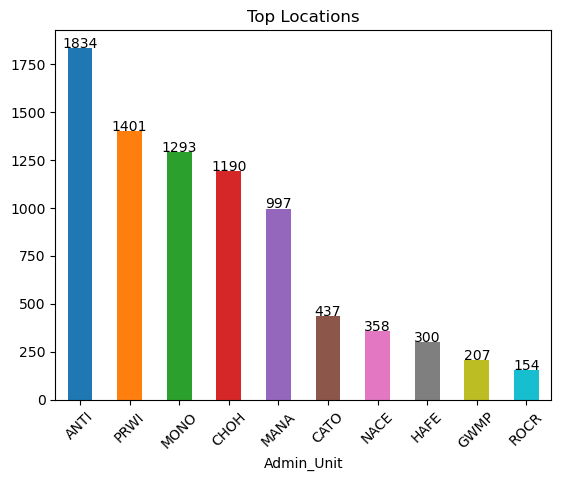

In [69]:
top_locations = final_df.groupby('Admin_Unit')['Count'].sum() \
                       .sort_values(ascending=False).head(10)


colors = plt.cm.tab10.colors

ax = top_locations.plot(kind='bar', color=colors)

plt.title("Top Locations")
plt.xticks(rotation=45)

# Data labels
for i, v in enumerate(top_locations):
    ax.text(i, v + 1, str(v), ha='center')

plt.show()

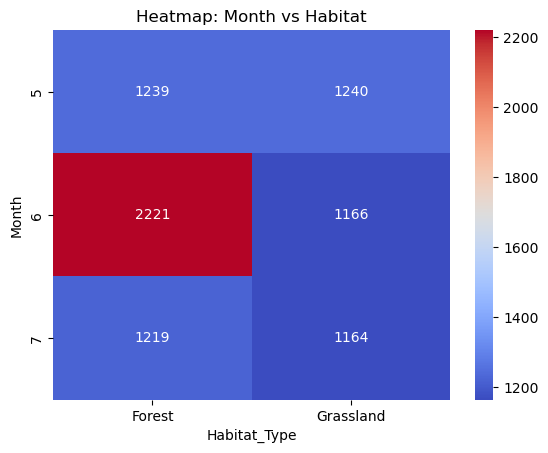

In [71]:
import seaborn as sns

pivot = final_df.pivot_table(
    values='Count',
    index='Month',
    columns='Habitat_Type',
    aggfunc='sum'
)

sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt='g')

plt.title("Heatmap: Month vs Habitat")
plt.show()

In [73]:
plt.style.use('ggplot')

In [77]:
final_df.to_csv("cleaned_bird_data1.csv", index=False)

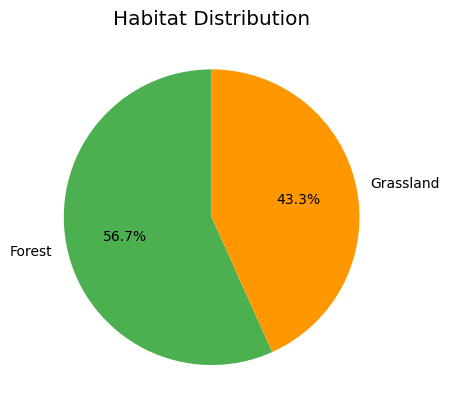

In [79]:
habitat_data = final_df.groupby('Habitat_Type')['Count'].sum()

plt.pie(
    habitat_data,
    labels=habitat_data.index,
    autopct='%1.1f%%',
    colors=['#4CAF50', '#FF9800'],
    startangle=90
)

plt.title("Habitat Distribution")
plt.show()

In [81]:
final_df.to_excel("cleaned_bird_data2.xlsx", index=False)

SyntaxError: invalid syntax (2750750326.py, line 1)